# Nova Corrected Dataset Exploration

This notebook compares the original synthetic parquet tables with the corrected BigQuery-ready parquet outputs in `data/corrected/`.

The goal is not deep modeling. The goal is to quickly check whether the corrected tables now behave more like a real global super-app dataset: growth, seasonality, market geography, merchant concentration, category-specific basket sizes, and non-flat reliability patterns.

## 1. Setup

Use Polars lazy scans for the interaction tables. Dimension tables and aggregate outputs are small enough to collect eagerly.

In [78]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(80)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

NOTEBOOK_CWD = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_CWD if (NOTEBOOK_CWD / "data").exists() else NOTEBOOK_CWD.parent

RAW_DIR = REPO_ROOT / "data" / "raw"
CORRECTED_DIR = REPO_ROOT / "data" / "corrected"
QA_DIR = CORRECTED_DIR / "qa"

RAW_INTERACTIONS = RAW_DIR / "nova_interactions.parquet"
CORRECTED_INTERACTIONS_GLOB = str(CORRECTED_DIR / "nova_interactions" / "month=*" / "*.parquet")

print("Repo root:", REPO_ROOT)
print("Corrected interactions glob:", CORRECTED_INTERACTIONS_GLOB)

Repo root: /Users/doruk/dev/nova-analytics
Corrected interactions glob: /Users/doruk/dev/nova-analytics/data/corrected/nova_interactions/month=*/*.parquet


In [79]:
raw_interactions = pl.scan_parquet(RAW_INTERACTIONS)
corrected_interactions = pl.scan_parquet(CORRECTED_INTERACTIONS_GLOB)

raw_users = pl.read_parquet(RAW_DIR / "nova_users.parquet")
raw_services = pl.read_parquet(RAW_DIR / "nova_services.parquet")

corrected_users = pl.read_parquet(CORRECTED_DIR / "nova_users.parquet")
corrected_services = pl.read_parquet(CORRECTED_DIR / "nova_services.parquet")
markets = pl.read_parquet(CORRECTED_DIR / "nova_markets.parquet")

metadata_path = CORRECTED_DIR / "_generation_metadata.json"
metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}

display(pd.DataFrame([metadata]).T.rename(columns={0: "value"}))

,value
generated_at,2026-06-15T10:06:40Z
seed,20260609
target_rows,50000000
batch_size,1000000
enable_weather_effects,True
enable_fraud_behavior,True
month_counts,"{'2024-01': 3300000, '2024-02': 3200000, '2024..."
source_raw_dir,data/raw
output_dir,data/corrected


## 2. BigQuery readiness snapshot

This table is generated by `scripts/validate_corrected_dataset.py`. It should be the first sanity check before BigQuery ingestion.

In [80]:
checks_path = QA_DIR / "validation_checks.csv"
if checks_path.exists():
    validation_checks = pl.read_csv(checks_path)
    display(validation_checks.to_pandas())
else:
    print("No validation checks found. Run scripts/validate_corrected_dataset.py first.")

,check,status,detail
0,Exact target row count,PASS,"50,000,000 / 50,000,000"
1,Non-partitioned interactions file exists,PASS,data/corrected/nova_interactions.parquet
2,Non-partitioned row count matches partitions,PASS,"50,000,000 / 50,000,000"
3,Non-partitioned schema matches partitions,PASS,match
4,Non-partitioned monthly totals match partitions,PASS,max row diff 0; max amount diff $0.00
5,Unique Transaction_UUID,PASS,"50,000,000 unique"
6,All required columns present,PASS,all present
7,Zero nulls in required columns,PASS,0 nulls
8,Full date coverage,PASS,0 missing dates
9,Category matches service category,PASS,0 mismatches


## 3. Structural comparison

The corrected data should keep the same core analytical shape while fixing category-service consistency and date coverage.

In [81]:
def structural_profile(name: str, interactions_lf: pl.LazyFrame, services_df: pl.DataFrame) -> pl.DataFrame:
    base = interactions_lf.select(
        pl.len().alias("n_rows"),
        pl.col("Transaction_UUID").n_unique().alias("unique_transactions"),
        pl.col("User_ID").n_unique().alias("active_users"),
        pl.col("Service_ID").n_unique().alias("active_services"),
        pl.col("Date").min().alias("min_date"),
        pl.col("Date").max().alias("max_date"),
        pl.col("Date").n_unique().alias("n_dates"),
    ).collect()

    mismatches = (
        interactions_lf.select("Service_ID", "Category")
        .join(
            services_df.select("Service_ID", pl.col("Category").alias("Service_Category")).lazy(),
            on="Service_ID",
            how="left",
        )
        .select((pl.col("Category") != pl.col("Service_Category")).sum().alias("category_mismatches"))
        .collect()
    )
    return base.with_columns(
        pl.lit(name).alias("dataset"),
        pl.lit(mismatches.item()).alias("category_mismatches"),
    ).select("dataset", "n_rows", "unique_transactions", "active_users", "active_services", "min_date", "max_date", "n_dates", "category_mismatches")

profiles = pl.concat([
    structural_profile("raw", raw_interactions, raw_services),
    structural_profile("corrected", corrected_interactions, corrected_services),
])

display(profiles.to_pandas())

,dataset,n_rows,unique_transactions,active_users,active_services,min_date,max_date,n_dates,category_mismatches
0,raw,50000000,50000000,2000000,50000,2024-01-01,2024-12-30,365,40018166
1,corrected,50000000,50000000,1706352,50000,2024-01-01,2024-12-31,366,0


## 4. Monthly growth and GMV

Raw volume mostly reflects month length. Corrected volume should show a clear growth story with stronger Q4 activity.

,Month,n_transactions,active_users,total_amount_usd,avg_amount_usd,completion_rate,dataset
0,2024-01-01,4250104,1761812,3.293702e+08,77.496970,0.899964,raw
1,2024-02-01,3969517,1725261,3.076242e+08,77.496640,0.900115,raw
2,2024-03-01,4249167,1761213,3.292384e+08,77.483036,0.899858,raw
3,2024-04-01,4108065,1743657,3.184576e+08,77.520107,0.899917,raw
4,2024-05-01,4243308,1760549,3.288600e+08,77.500847,0.900332,raw
5,2024-06-01,4109448,1743595,3.184341e+08,77.488279,0.899867,raw
6,2024-07-01,4248893,1760868,3.293618e+08,77.517078,0.900015,raw
7,2024-08-01,4247766,1760672,3.290824e+08,77.471866,0.899966,raw
8,2024-09-01,4108238,1743417,3.184347e+08,77.511265,0.899990,raw
9,2024-10-01,4245011,1760229,3.290288e+08,77.509528,0.900072,raw


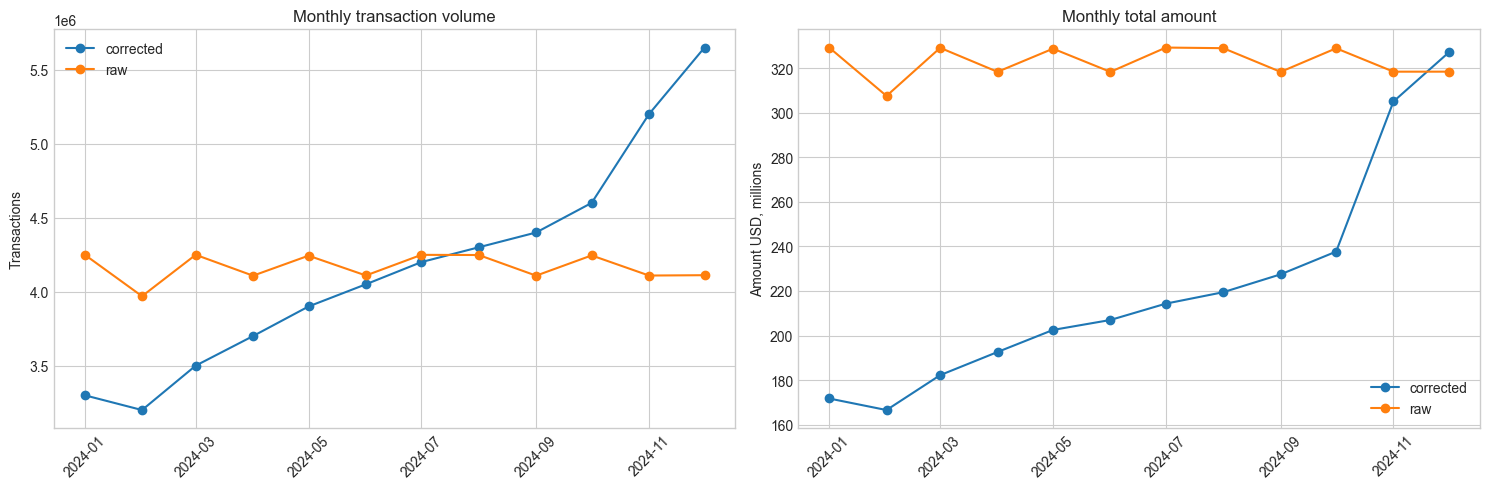

In [82]:
def monthly_kpis(name: str, lf: pl.LazyFrame) -> pl.DataFrame:
    return (
        lf.group_by("Month")
        .agg(
            pl.len().alias("n_transactions"),
            pl.col("User_ID").n_unique().alias("active_users"),
            pl.col("Amount_USD").sum().alias("total_amount_usd"),
            pl.col("Amount_USD").mean().alias("avg_amount_usd"),
            (pl.col("Status") == "Completed").mean().alias("completion_rate"),
        )
        .with_columns(pl.lit(name).alias("dataset"))
        .sort("Month")
        .collect()
    )

monthly = pl.concat([
    monthly_kpis("raw", raw_interactions),
    monthly_kpis("corrected", corrected_interactions),
])
monthly_pd = monthly.to_pandas()
display(monthly_pd)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for dataset, df in monthly_pd.groupby("dataset"):
    axes[0].plot(df["Month"], df["n_transactions"], marker="o", label=dataset)
    axes[1].plot(df["Month"], df["total_amount_usd"] / 1_000_000, marker="o", label=dataset)
axes[0].set_title("Monthly transaction volume")
axes[0].set_ylabel("Transactions")
axes[1].set_title("Monthly total amount")
axes[1].set_ylabel("Amount USD, millions")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
plt.tight_layout()
plt.show()

,dataset,n_dates,avg_daily_transactions,std_daily_transactions,daily_cv
0,corrected,366,136612.021858,24096.275356,0.176385
1,raw,365,136986.301370,368.603881,0.002691


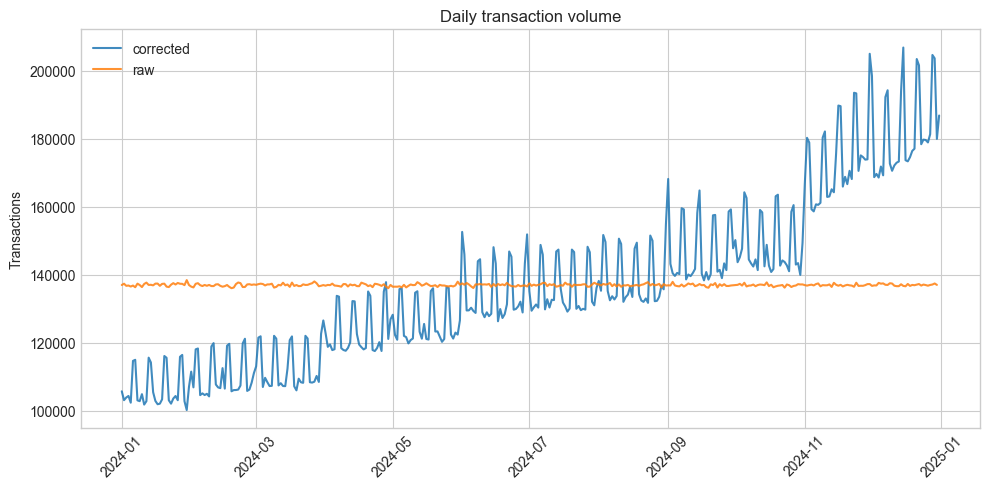

In [83]:
daily = pl.concat([
    raw_interactions.group_by("Date").agg(pl.len().alias("n_transactions")).with_columns(pl.lit("raw").alias("dataset")).collect(),
    corrected_interactions.group_by("Date").agg(pl.len().alias("n_transactions")).with_columns(pl.lit("corrected").alias("dataset")).collect(),
])

daily_stats = (
    daily.group_by("dataset")
    .agg(
        pl.len().alias("n_dates"),
        pl.col("n_transactions").mean().alias("avg_daily_transactions"),
        pl.col("n_transactions").std().alias("std_daily_transactions"),
        (pl.col("n_transactions").std() / pl.col("n_transactions").mean()).alias("daily_cv"),
    )
    .sort("dataset")
)
display(daily_stats.to_pandas())

daily_pd = daily.sort(["dataset", "Date"]).to_pandas()
for dataset, df in daily_pd.groupby("dataset"):
    plt.plot(df["Date"], df["n_transactions"], alpha=0.85, label=dataset)
plt.title("Daily transaction volume")
plt.ylabel("Transactions")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Category behavior

Corrected categories should differ by basket size and completion behavior. Raw category averages were almost identical.

,Category,n_transactions,active_users,avg_amount_usd,median_amount_usd,completion_rate,transaction_share,dataset
0,Digital Wallet,4998004,1835664,77.485762,77.47,0.899899,0.099960,raw
1,E-Commerce,9997890,1986665,77.478125,77.47,0.900000,0.199958,raw
2,Food Delivery,20003439,1999892,77.512168,77.52,0.899976,0.400069,raw
3,Grocery,4998923,1836666,77.511723,77.54,0.900299,0.099978,raw
4,Ride Hailing,10001744,1986565,77.493836,77.50,0.900021,0.200035,raw
5,Digital Wallet,6011860,1254842,46.446698,24.26,0.965670,0.120237,corrected
6,E-Commerce,11003532,1481296,101.148257,70.44,0.865275,0.220071,corrected
7,Food Delivery,14864352,1563875,28.858344,25.37,0.937703,0.297287,corrected
8,Grocery,6914165,1319101,75.235007,67.18,0.915641,0.138283,corrected
9,Ride Hailing,11206091,1485337,27.884751,23.52,0.880549,0.224122,corrected


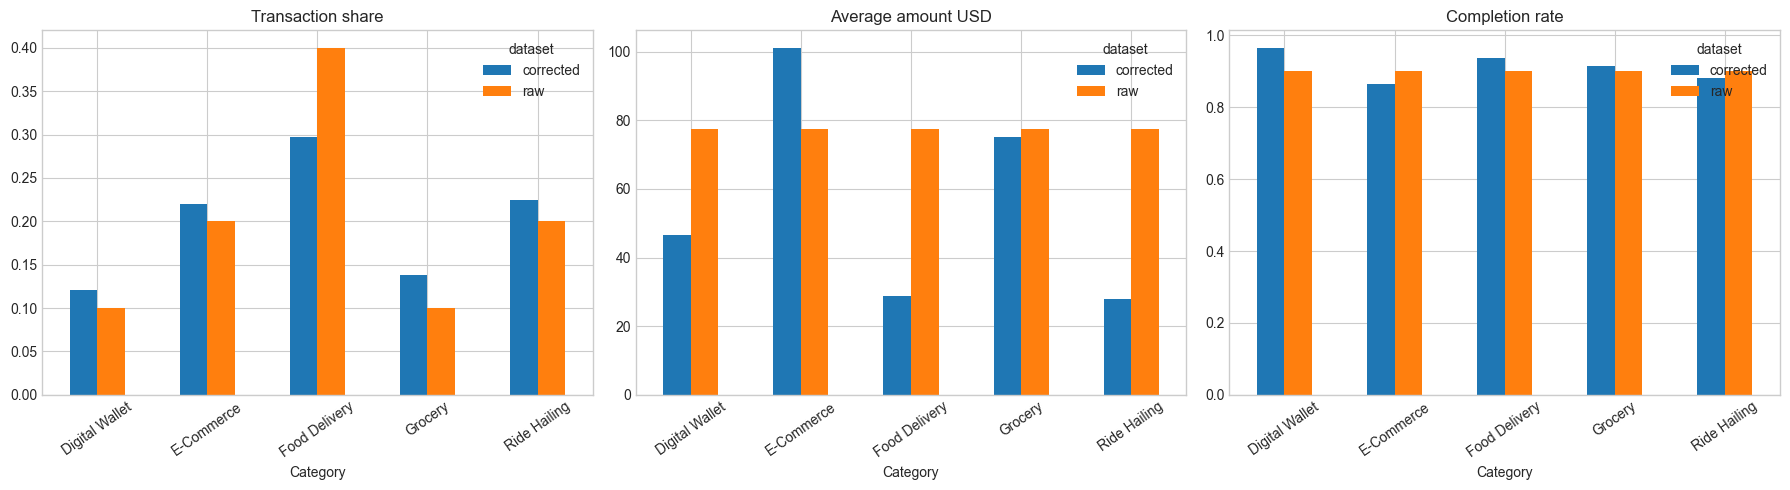

In [84]:
def category_kpis(name: str, lf: pl.LazyFrame) -> pl.DataFrame:
    return (
        lf.group_by("Category")
        .agg(
            pl.len().alias("n_transactions"),
            pl.col("User_ID").n_unique().alias("active_users"),
            pl.col("Amount_USD").mean().alias("avg_amount_usd"),
            pl.col("Amount_USD").median().alias("median_amount_usd"),
            (pl.col("Status") == "Completed").mean().alias("completion_rate"),
        )
        .with_columns(
            (pl.col("n_transactions") / pl.col("n_transactions").sum()).alias("transaction_share"),
            pl.lit(name).alias("dataset"),
        )
        .sort(["dataset", "Category"])
        .collect()
    )

category_compare = pl.concat([
    category_kpis("raw", raw_interactions),
    category_kpis("corrected", corrected_interactions),
])
cat_pd = category_compare.to_pandas()
display(cat_pd)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for metric, ax, title in [
    ("transaction_share", axes[0], "Transaction share"),
    ("avg_amount_usd", axes[1], "Average amount USD"),
    ("completion_rate", axes[2], "Completion rate"),
]:
    pivot = cat_pd.pivot(index="Category", columns="dataset", values=metric).sort_index()
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

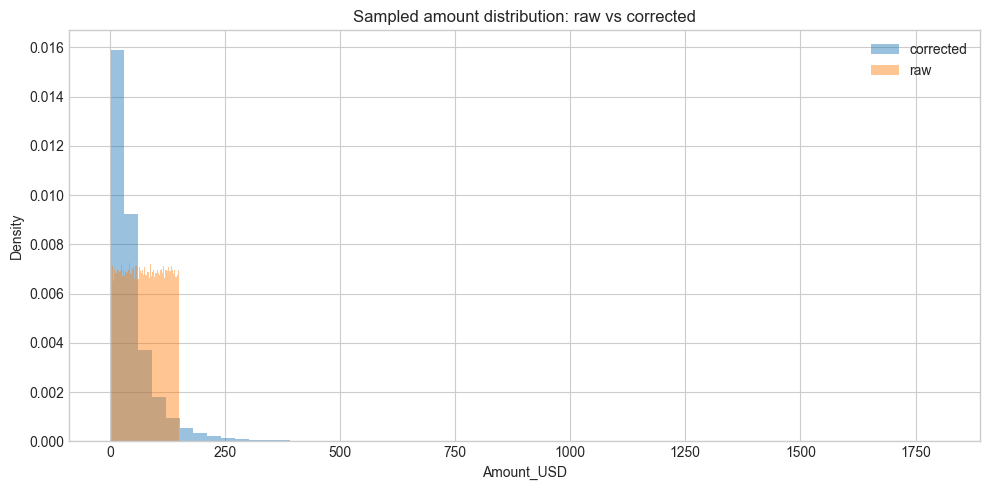

/var/folders/28/8k26_pcd2bz699b6mx6vz2yc0000gn/T/ipykernel_98521/3653704754.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([corrected_amounts.loc[corrected_amounts["Category"] == cat, "Amount_USD"] for cat in order], labels=order, showfliers=False)


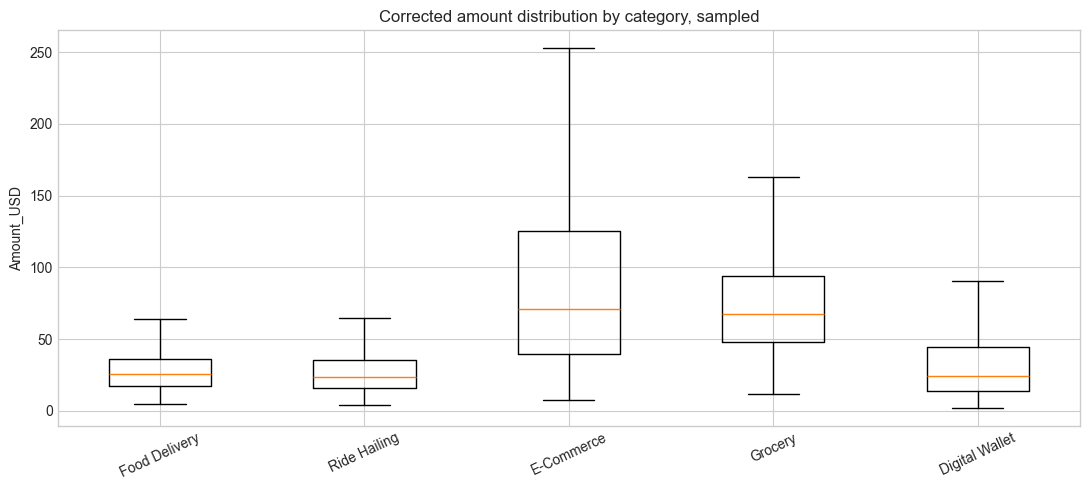

In [85]:
sample_mod = 500
amount_sample = pl.concat([
    raw_interactions
    .filter(pl.col("Transaction_UUID").hash(seed=42).mod(sample_mod) == 0)
    .select("Amount_USD", "Category")
    .with_columns(pl.lit("raw").alias("dataset"))
    .collect(),
    corrected_interactions
    .filter(pl.col("Transaction_UUID").hash(seed=42).mod(sample_mod) == 0)
    .select("Amount_USD", "Category")
    .with_columns(pl.lit("corrected").alias("dataset"))
    .collect(),
])
amount_pd = amount_sample.to_pandas()

plt.figure(figsize=(10, 5))
for dataset, df in amount_pd.groupby("dataset"):
    plt.hist(df["Amount_USD"], bins=60, alpha=0.45, density=True, label=dataset)
plt.title("Sampled amount distribution: raw vs corrected")
plt.xlabel("Amount_USD")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

corrected_amounts = amount_pd[amount_pd["dataset"] == "corrected"]
order = ["Food Delivery", "Ride Hailing", "E-Commerce", "Grocery", "Digital Wallet"]
plt.figure(figsize=(11, 5))
plt.boxplot([corrected_amounts.loc[corrected_amounts["Category"] == cat, "Amount_USD"] for cat in order], labels=order, showfliers=False)
plt.title("Corrected amount distribution by category, sampled")
plt.ylabel("Amount_USD")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 6. Hourly behavior

Raw hourly counts were almost perfectly flat. Corrected hourly behavior should have category-specific peaks.

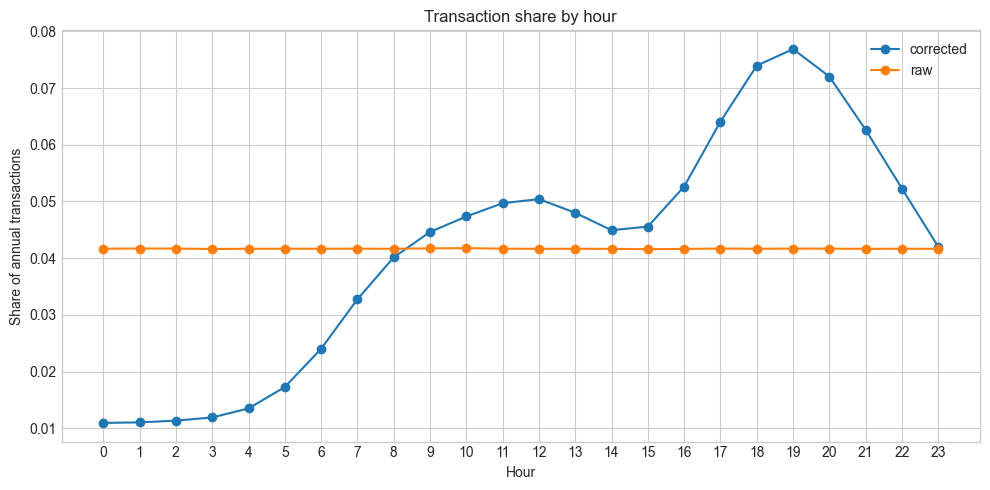

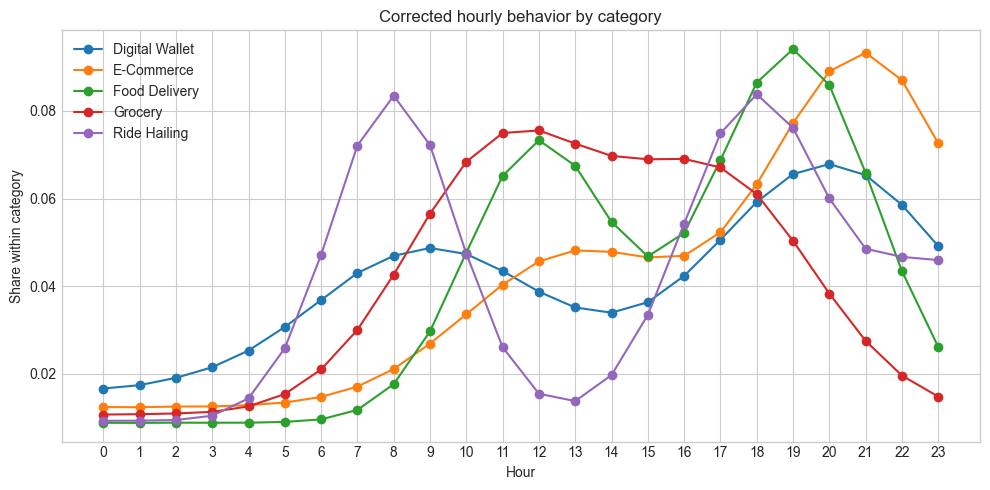

In [86]:
hourly_raw = raw_interactions.group_by("Hour").agg(pl.len().alias("n_transactions")).with_columns(pl.lit("raw").alias("dataset")).collect()
hourly_corrected = corrected_interactions.group_by("Hour").agg(pl.len().alias("n_transactions")).with_columns(pl.lit("corrected").alias("dataset")).collect()
hourly_compare = pl.concat([hourly_raw, hourly_corrected]).with_columns(
    (pl.col("n_transactions") / pl.col("n_transactions").sum().over("dataset")).alias("share")
)

hourly_pd = hourly_compare.sort(["dataset", "Hour"]).to_pandas()
for dataset, df in hourly_pd.groupby("dataset"):
    plt.plot(df["Hour"], df["share"], marker="o", label=dataset)
plt.title("Transaction share by hour")
plt.xlabel("Hour")
plt.ylabel("Share of annual transactions")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

hourly_category = (
    corrected_interactions.group_by(["Category", "Hour"])
    .agg(pl.len().alias("n_transactions"))
    .with_columns((pl.col("n_transactions") / pl.col("n_transactions").sum().over("Category")).alias("share"))
    .sort(["Category", "Hour"])
    .collect()
)
hourly_cat_pd = hourly_category.to_pandas()
for category, df in hourly_cat_pd.groupby("Category"):
    plt.plot(df["Hour"], df["share"], marker="o", label=category)
plt.title("Corrected hourly behavior by category")
plt.xlabel("Hour")
plt.ylabel("Share within category")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

## 7. Reliability by platform and category

Corrected completion and failure rates should vary by category and platform instead of staying fixed around 90/5/5 everywhere.

,Category,Status,n_transactions,dataset,status_share
0,Digital Wallet,Completed,5805472,corrected,0.965670
1,Digital Wallet,Failed,174877,corrected,0.029089
2,Digital Wallet,Refunded,31511,corrected,0.005241
3,E-Commerce,Completed,9521082,corrected,0.865275
4,E-Commerce,Failed,487445,corrected,0.044299
5,E-Commerce,Refunded,995005,corrected,0.090426
6,Food Delivery,Completed,13938342,corrected,0.937703
7,Food Delivery,Failed,599587,corrected,0.040337
8,Food Delivery,Refunded,326423,corrected,0.021960
9,Grocery,Completed,6330891,corrected,0.915641


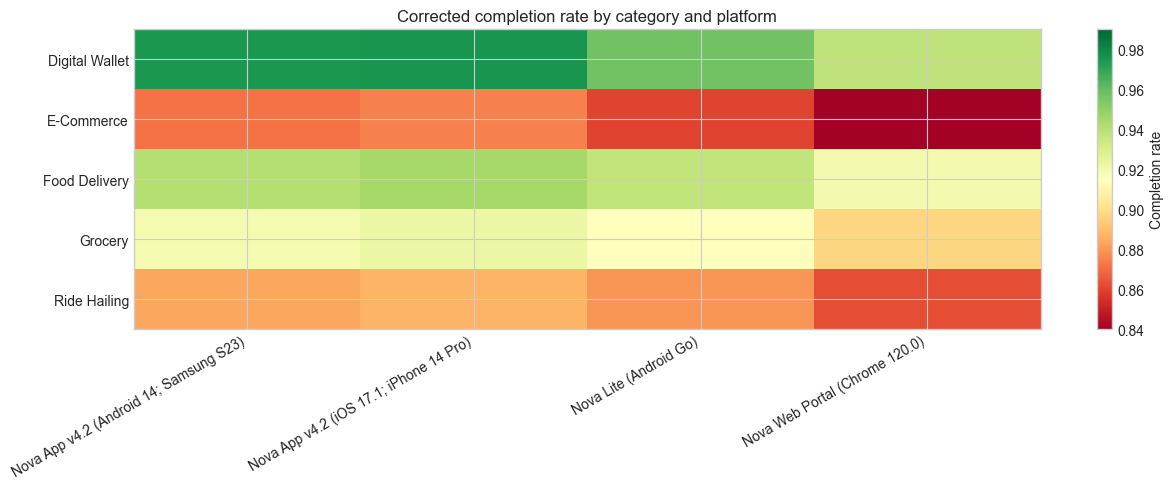

In [87]:
status_category = pl.concat([
    raw_interactions.group_by(["Category", "Status"]).agg(pl.len().alias("n_transactions")).with_columns(pl.lit("raw").alias("dataset")).collect(),
    corrected_interactions.group_by(["Category", "Status"]).agg(pl.len().alias("n_transactions")).with_columns(pl.lit("corrected").alias("dataset")).collect(),
]).with_columns(
    (pl.col("n_transactions") / pl.col("n_transactions").sum().over(["dataset", "Category"])).alias("status_share")
)
display(status_category.sort(["dataset", "Category", "Status"]).to_pandas())

completion_platform = (
    corrected_interactions.group_by(["Category", "Platform_User_Agent"])
    .agg((pl.col("Status") == "Completed").mean().alias("completion_rate"))
    .sort(["Category", "Platform_User_Agent"])
    .collect()
    .to_pandas()
)
pivot = completion_platform.pivot(index="Category", columns="Platform_User_Agent", values="completion_rate")

plt.figure(figsize=(13, 5))
plt.imshow(pivot.values, aspect="auto", vmin=0.84, vmax=0.99, cmap="RdYlGn")
plt.colorbar(label="Completion rate")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=30, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Corrected completion rate by category and platform")
plt.tight_layout()
plt.show()

## 8. Merchant concentration

A real super-app should have head merchants and long-tail merchants. The raw service counts were clustered around exactly 1,000 transactions per service.

,dataset,n_services,mean_transactions,std_transactions,cv_transactions,top_1pct_share,top_10_services_share
0,raw,50000,1000.0,31.567615,0.031568,0.010862,0.000225
1,corrected,50000,1000.0,2348.953890,2.348954,0.203054,0.008591


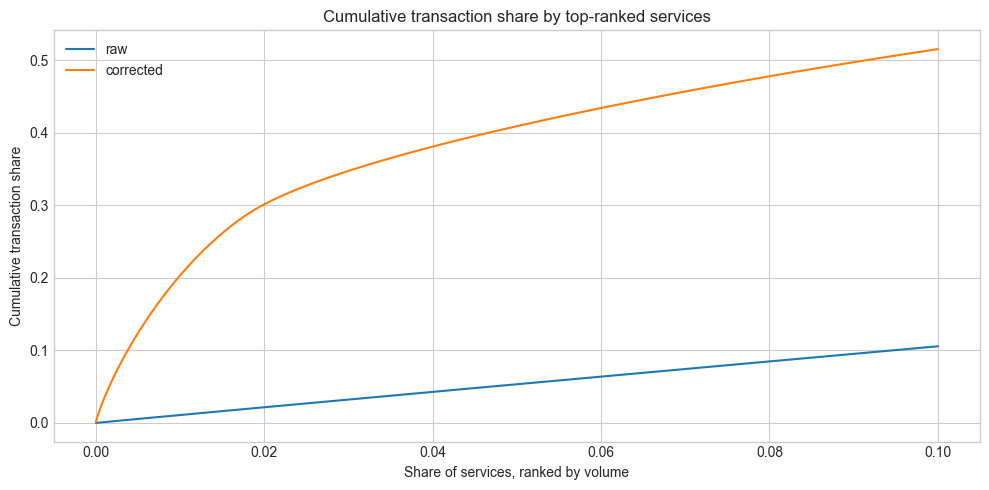

In [88]:
def service_concentration(name: str, lf: pl.LazyFrame) -> tuple[pl.DataFrame, dict]:
    counts = lf.group_by("Service_ID").agg(pl.len().alias("n_transactions")).sort("n_transactions", descending=True).collect()
    total = counts["n_transactions"].sum()
    top_1pct_n = max(1, int(counts.height * 0.01))
    stats = {
        "dataset": name,
        "n_services": counts.height,
        "mean_transactions": counts["n_transactions"].mean(),
        "std_transactions": counts["n_transactions"].std(),
        "cv_transactions": counts["n_transactions"].std() / counts["n_transactions"].mean(),
        "top_1pct_share": counts.head(top_1pct_n)["n_transactions"].sum() / total,
        "top_10_services_share": counts.head(10)["n_transactions"].sum() / total,
    }
    return counts.with_columns(pl.lit(name).alias("dataset")), stats

raw_service_counts, raw_service_stats = service_concentration("raw", raw_interactions)
corrected_service_counts, corrected_service_stats = service_concentration("corrected", corrected_interactions)
service_stats = pd.DataFrame([raw_service_stats, corrected_service_stats])
display(service_stats)

plt.figure(figsize=(10, 5))
for counts_df, label in [(raw_service_counts, "raw"), (corrected_service_counts, "corrected")]:
    counts = counts_df["n_transactions"].to_numpy()
    cumulative_share = np.cumsum(counts) / counts.sum()
    service_rank_share = np.arange(1, len(counts) + 1) / len(counts)
    plt.plot(service_rank_share[:5000], cumulative_share[:5000], label=label)
plt.title("Cumulative transaction share by top-ranked services")
plt.xlabel("Share of services, ranked by volume")
plt.ylabel("Cumulative transaction share")
plt.legend()
plt.tight_layout()
plt.show()

## 9. User lifecycle and corrected dimensions

The corrected user table adds lifecycle and market fields so dashboard segments are not all identical.

,User_Segment,Lifecycle_Segment,Membership_Tier,n_users,user_share
0,Casual,Retained,Standard,466142,0.233071
1,Regular,Retained,Standard,323356,0.161678
2,Dormant,Inactive,Standard,288153,0.144076
3,Casual,At Risk,Standard,218764,0.109382
4,Regular,Retained,Gold,204193,0.102096
5,New,New Active,Standard,130128,0.065064
6,Power,High Value,Gold,91599,0.045799
7,Power,High Value,Platinum,63928,0.031964
8,Regular,Retained,Platinum,48066,0.024033
9,Casual,Retained,Gold,46757,0.023378


,dataset,active_users,avg_transactions,median_transactions,p95_transactions
0,raw,2000000,25.000000,25.0,33.0
1,corrected,1706352,29.302278,12.0,145.0


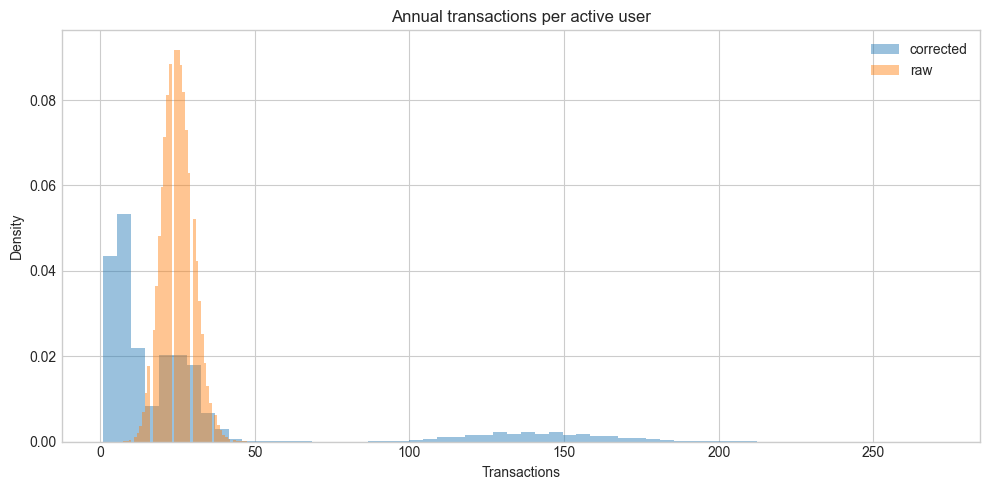

In [89]:
user_segment_profile = (
    corrected_users.group_by(["User_Segment", "Lifecycle_Segment", "Membership_Tier"])
    .agg(pl.len().alias("n_users"))
    .with_columns((pl.col("n_users") / corrected_users.height).alias("user_share"))
    .sort("n_users", descending=True)
)
display(user_segment_profile.to_pandas())

active_user_counts = pl.concat([
    raw_interactions.group_by("User_ID").agg(pl.len().alias("n_transactions")).with_columns(pl.lit("raw").alias("dataset")).collect(),
    corrected_interactions.group_by("User_ID").agg(pl.len().alias("n_transactions")).with_columns(pl.lit("corrected").alias("dataset")).collect(),
])
activity_stats = (
    active_user_counts.group_by("dataset")
    .agg(
        pl.len().alias("active_users"),
        pl.col("n_transactions").mean().alias("avg_transactions"),
        pl.col("n_transactions").median().alias("median_transactions"),
        pl.col("n_transactions").quantile(0.95).alias("p95_transactions"),
    )
)
display(activity_stats.to_pandas())

activity_pd = active_user_counts.to_pandas()
plt.figure(figsize=(10, 5))
for dataset, df in activity_pd.groupby("dataset"):
    plt.hist(df["n_transactions"], bins=60, alpha=0.45, density=True, label=dataset)
plt.title("Annual transactions per active user")
plt.xlabel("Transactions")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Markets and geography

Raw GPS was globally uniform. Corrected GPS is market-centered and should support realistic market maps.

,Market_ID,Market_Name,Region,n_transactions,active_users,total_amount_usd,transaction_share
0,2,Jakarta,Southeast Asia,4732277,153939,2.029075e+08,0.094646
1,13,Mumbai,South Asia,4308982,136621,1.389326e+08,0.086180
2,3,Manila,Southeast Asia,3873683,128554,1.776192e+08,0.077474
3,14,Bangalore,South Asia,3760040,119520,1.404919e+08,0.075201
4,1,Singapore,Southeast Asia,3338771,118993,2.170819e+08,0.066775
5,4,Bangkok,Southeast Asia,3266776,110829,1.520880e+08,0.065336
6,6,Istanbul,EMEA,3165595,110574,1.510523e+08,0.063312
7,5,Ho Chi Minh City,Southeast Asia,3089764,102613,1.246640e+08,0.061795
8,12,Sao Paulo,Latin America,2983733,102192,1.171654e+08,0.059675
9,10,New York,North America,2975216,110479,2.463339e+08,0.059504


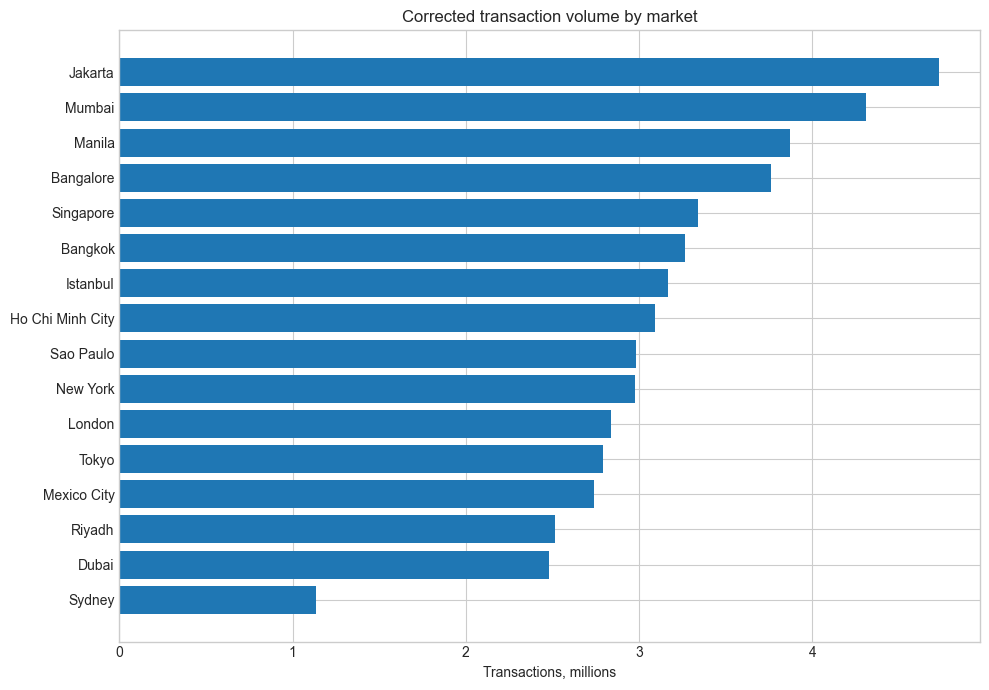

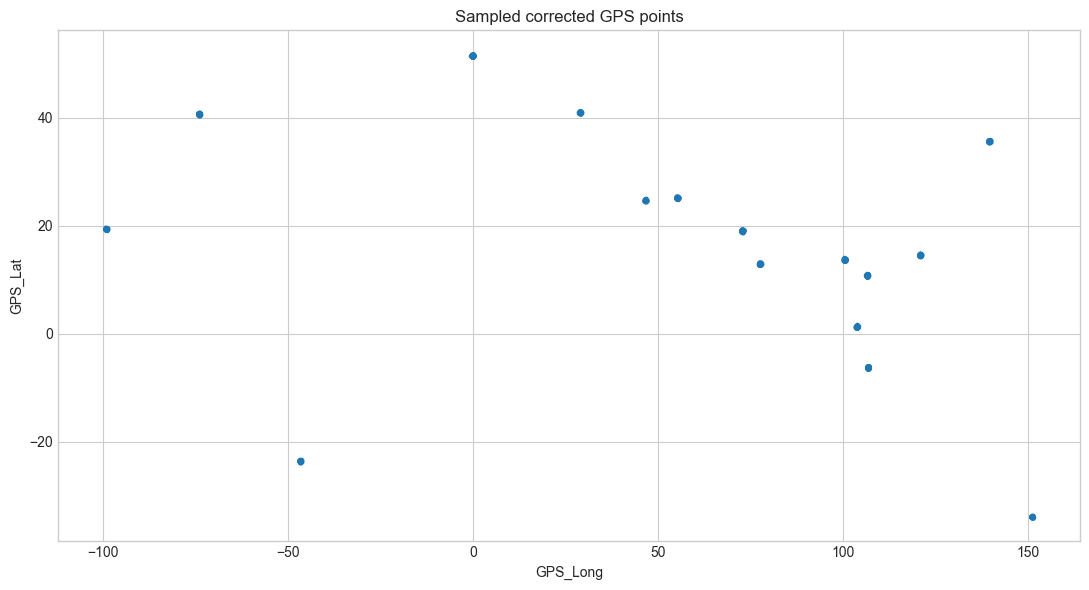

In [90]:
market_kpis = (
    corrected_interactions.group_by(["Market_ID", "Market_Name", "Region"])
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("User_ID").n_unique().alias("active_users"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
    )
    .with_columns((pl.col("n_transactions") / pl.col("n_transactions").sum()).alias("transaction_share"))
    .sort("n_transactions", descending=True)
    .collect()
)
display(market_kpis.to_pandas())

market_pd = market_kpis.to_pandas().sort_values("n_transactions")
plt.figure(figsize=(10, 7))
plt.barh(market_pd["Market_Name"], market_pd["n_transactions"] / 1_000_000)
plt.title("Corrected transaction volume by market")
plt.xlabel("Transactions, millions")
plt.tight_layout()
plt.show()

geo_sample = (
    corrected_interactions
    .filter(pl.col("Transaction_UUID").hash(seed=7).mod(5000) == 0)
    .select("GPS_Long", "GPS_Lat", "Market_Name")
    .collect()
    .to_pandas()
)
plt.figure(figsize=(11, 6))
plt.scatter(geo_sample["GPS_Long"], geo_sample["GPS_Lat"], s=4, alpha=0.35)
plt.title("Sampled corrected GPS points")
plt.xlabel("GPS_Long")
plt.ylabel("GPS_Lat")
plt.tight_layout()
plt.show()

## 11. Ingestion file parity and generation phase flags

The corrected pipeline now writes both partitioned interaction parquet and a non-partitioned `nova_interactions.parquet` file for ingestion. This section confirms that the notebook is reading the same analytical content from both layouts and records which generation behaviors were enabled.


In [91]:
CORRECTED_INTERACTIONS_SINGLE = CORRECTED_DIR / "nova_interactions.parquet"

phase_flags = {
    "enable_weather_effects": bool(metadata.get("enable_weather_effects", False)),
    "enable_fraud_behavior": bool(metadata.get("enable_fraud_behavior", False)),
    "has_non_partitioned_interactions": CORRECTED_INTERACTIONS_SINGLE.exists(),
}
display(pd.DataFrame([phase_flags]).T.rename(columns={0: "value"}))

if CORRECTED_INTERACTIONS_SINGLE.exists():
    corrected_interactions_single = pl.scan_parquet(CORRECTED_INTERACTIONS_SINGLE)
    partitioned_profile = (
        corrected_interactions
        .group_by("Month")
        .agg(
            pl.len().alias("partitioned_rows"),
            pl.col("Amount_USD").sum().alias("partitioned_amount_usd"),
        )
        .sort("Month")
        .collect()
    )
    single_profile = (
        corrected_interactions_single
        .group_by("Month")
        .agg(
            pl.len().alias("single_rows"),
            pl.col("Amount_USD").sum().alias("single_amount_usd"),
        )
        .sort("Month")
        .collect()
    )
    parity = (
        partitioned_profile
        .join(single_profile, on="Month", how="inner")
        .with_columns(
            (pl.col("partitioned_rows") - pl.col("single_rows")).alias("row_diff"),
            (pl.col("partitioned_amount_usd") - pl.col("single_amount_usd")).round(2).alias("amount_diff"),
        )
    )
    display(parity.to_pandas())
else:
    print("No non-partitioned interactions parquet found. Regenerate with the updated generator before final ingestion QA.")


,value
enable_weather_effects,True
enable_fraud_behavior,True
has_non_partitioned_interactions,True


,Month,partitioned_rows,partitioned_amount_usd,single_rows,single_amount_usd,row_diff,amount_diff
0,2024-01-01,3300000,1.717026e+08,3300000,1.717026e+08,0,0.0
1,2024-02-01,3200000,1.665112e+08,3200000,1.665112e+08,0,-0.0
2,2024-03-01,3500000,1.821980e+08,3500000,1.821980e+08,0,-0.0
3,2024-04-01,3700000,1.925885e+08,3700000,1.925885e+08,0,-0.0
4,2024-05-01,3900000,2.025072e+08,3900000,2.025072e+08,0,-0.0
5,2024-06-01,4050000,2.069769e+08,4050000,2.069769e+08,0,0.0
6,2024-07-01,4200000,2.143247e+08,4200000,2.143247e+08,0,0.0
7,2024-08-01,4300000,2.194591e+08,4300000,2.194591e+08,0,0.0
8,2024-09-01,4400000,2.274766e+08,4400000,2.274766e+08,0,0.0
9,2024-10-01,4600000,2.376954e+08,4600000,2.376954e+08,0,0.0


## 12. Customer behavior deep dive

This section checks whether user lifecycle and membership dimensions now create meaningful behavioral differences: active-user rates, repeat activity, multi-category use, spend, and non-completion.


,User_Segment,Lifecycle_Segment,Membership_Tier,users,active_user_rate,repeat_user_rate,multi_category_user_rate,avg_transactions,p95_transactions,avg_active_months,avg_total_amount_usd,avg_non_completion_rate
0,Casual,Retained,Standard,466142,1.0,0.995402,0.987663,7.498458,12.0,5.514689,350.665921,0.091761
1,Regular,Retained,Standard,323356,1.0,1.000000,1.000000,24.093235,33.0,10.279098,1129.746079,0.093159
2,Dormant,Inactive,Standard,288153,1.0,0.017608,0.013430,0.035863,0.0,0.035450,1.432083,0.117972
3,Casual,At Risk,Standard,218764,1.0,0.966561,0.936711,5.098618,9.0,4.093736,220.526103,0.108933
4,Regular,Retained,Gold,204193,1.0,1.000000,1.000000,27.979632,38.0,10.723962,1415.507633,0.088610
5,New,New Active,Standard,130128,1.0,0.951979,0.926499,6.783014,14.0,4.105642,313.736960,0.100979
6,Power,High Value,Gold,91599,1.0,1.000000,1.000000,139.324414,165.0,11.999651,7756.618737,0.086404
7,Power,High Value,Platinum,63928,1.0,1.000000,1.000000,162.032975,190.0,11.999812,9853.493547,0.081814
8,Regular,Retained,Platinum,48066,1.0,1.000000,1.000000,32.563246,43.0,11.104315,1799.372692,0.084410
9,Casual,Retained,Gold,46757,1.0,0.998674,0.994909,8.714738,14.0,6.121800,440.059114,0.087466


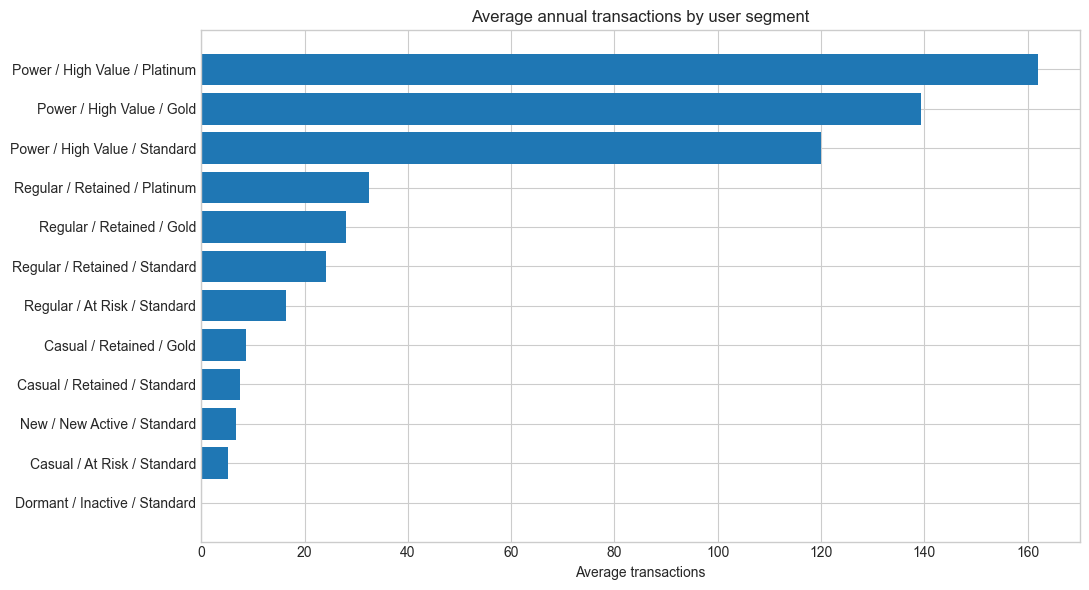

,Month,User_Segment,Lifecycle_Segment,n_transactions,active_users,total_amount_usd,non_completion_rate
0,2024-01-01,Casual,At Risk,85094,70632,3.646623e+06,0.118269
1,2024-01-01,Casual,Retained,265139,206373,1.222479e+07,0.093902
2,2024-01-01,Dormant,Inactive,732,731,2.759950e+04,0.112022
3,2024-01-01,New,New Active,7174,4888,3.256801e+05,0.115835
4,2024-01-01,Power,High Value,1902685,199049,1.055463e+08,0.085467
5,2024-01-01,Regular,At Risk,26361,15878,1.110493e+06,0.115815
6,2024-01-01,Regular,Retained,1012815,472734,4.882116e+07,0.093409
7,2024-02-01,Casual,At Risk,82047,68816,3.492787e+06,0.113959
8,2024-02-01,Casual,Retained,256901,201427,1.189658e+07,0.095188
9,2024-02-01,Dormant,Inactive,708,707,2.617379e+04,0.112994


In [92]:
user_activity = (
    corrected_interactions
    .group_by("User_ID")
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
        pl.col("Category").n_unique().alias("n_categories"),
        pl.col("Service_ID").n_unique().alias("n_services"),
        pl.col("Month").n_unique().alias("active_months"),
        (pl.col("Status") != "Completed").sum().alias("non_completed_transactions"),
        pl.col("Timestamp_dt").min().alias("first_transaction_at"),
        pl.col("Timestamp_dt").max().alias("last_transaction_at"),
    )
    .collect()
)

user_behavior = (
    corrected_users
    .join(user_activity, on="User_ID", how="left")
    .with_columns(
        pl.col("n_transactions").fill_null(0),
        pl.col("total_amount_usd").fill_null(0),
        pl.col("n_categories").fill_null(0),
        pl.col("n_services").fill_null(0),
        pl.col("active_months").fill_null(0),
        pl.col("non_completed_transactions").fill_null(0),
        (pl.col("n_transactions") > 0).alias("is_active_user"),
        (pl.col("n_transactions") > 1).alias("is_repeat_user"),
        (pl.col("n_categories") >= 2).alias("is_multi_category_user"),
        pl.when(pl.col("n_transactions") > 0)
        .then(pl.col("non_completed_transactions") / pl.col("n_transactions"))
        .otherwise(None)
        .alias("non_completion_rate"),
    )
)

segment_behavior = (
    user_behavior
    .group_by(["User_Segment", "Lifecycle_Segment", "Membership_Tier"])
    .agg(
        pl.len().alias("users"),
        pl.col("is_active_user").mean().alias("active_user_rate"),
        pl.col("is_repeat_user").mean().alias("repeat_user_rate"),
        pl.col("is_multi_category_user").mean().alias("multi_category_user_rate"),
        pl.col("n_transactions").mean().alias("avg_transactions"),
        pl.col("n_transactions").quantile(0.95).alias("p95_transactions"),
        pl.col("active_months").mean().alias("avg_active_months"),
        pl.col("total_amount_usd").mean().alias("avg_total_amount_usd"),
        pl.col("non_completion_rate").mean().alias("avg_non_completion_rate"),
    )
    .sort("users", descending=True)
)
display(segment_behavior.to_pandas())

segment_plot = segment_behavior.to_pandas().head(12).sort_values("avg_transactions")
plt.figure(figsize=(11, 6))
plt.barh(
    segment_plot["User_Segment"] + " / " + segment_plot["Lifecycle_Segment"] + " / " + segment_plot["Membership_Tier"],
    segment_plot["avg_transactions"],
)
plt.title("Average annual transactions by user segment")
plt.xlabel("Average transactions")
plt.tight_layout()
plt.show()

monthly_segment = (
    corrected_interactions
    .group_by(["Month", "User_Segment", "Lifecycle_Segment"])
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("User_ID").n_unique().alias("active_users"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
        (pl.col("Status") != "Completed").mean().alias("non_completion_rate"),
    )
    .sort(["Month", "User_Segment", "Lifecycle_Segment"])
    .collect()
)
display(monthly_segment.head(20).to_pandas())


## 13. Category, service, and market behavior

The regenerated dataset should avoid one-size-fits-all category shares. Here we inspect category mix by market, service supply by tier, service-category alignment, and market/category reliability.


,rows_checked,category_mismatches
0,50000000,0


,Market_ID,Market_Name,Region,Category,n_transactions,total_amount_usd,avg_amount_usd,completion_rate,active_users,active_services,market_category_share
0,14,Bangalore,South Asia,Food Delivery,1007592,2.053566e+07,20.380926,0.930100,109347,945,0.267974
1,14,Bangalore,South Asia,Ride Hailing,881614,1.771927e+07,20.098671,0.872473,106784,854,0.234469
2,14,Bangalore,South Asia,E-Commerce,861648,5.938282e+07,68.917721,0.856892,106398,748,0.229159
3,14,Bangalore,South Asia,Digital Wallet,531532,1.836492e+07,34.550930,0.962736,94694,460,0.141363
4,14,Bangalore,South Asia,Grocery,477654,2.448924e+07,51.269839,0.903951,92231,460,0.127034
...,...,...,...,...,...,...,...,...,...,...,...
75,15,Tokyo,East Asia,E-Commerce,790226,1.000318e+08,126.586293,0.873722,92224,819,0.282949
76,15,Tokyo,East Asia,Food Delivery,692886,2.482584e+07,35.829613,0.949147,89773,714,0.248095
77,15,Tokyo,East Asia,Ride Hailing,546464,1.898569e+07,34.742805,0.892906,85207,598,0.195667
78,15,Tokyo,East Asia,Grocery,460301,4.345942e+07,94.415227,0.924612,81428,520,0.164816


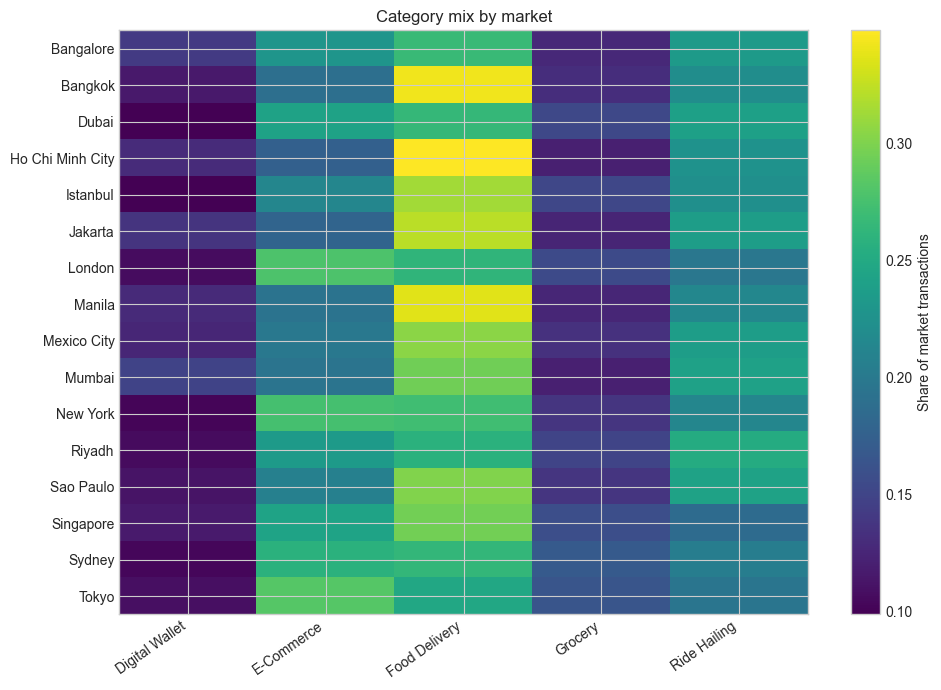

,Market_ID,Market_Name,Region,Category,Service_Tier,services,avg_rating,avg_popularity_score
0,14,Bangalore,South Asia,Digital Wallet,Head,12,4.608333,39.255180
1,14,Bangalore,South Asia,Digital Wallet,Long Tail,362,4.395856,1.378672
2,14,Bangalore,South Asia,Digital Wallet,Mid,86,4.470930,4.796019
3,14,Bangalore,South Asia,E-Commerce,Head,11,4.536364,36.793807
4,14,Bangalore,South Asia,E-Commerce,Long Tail,591,4.395093,1.337147
...,...,...,...,...,...,...,...,...
234,15,Tokyo,East Asia,Grocery,Long Tail,410,4.374146,1.370351
235,15,Tokyo,East Asia,Grocery,Mid,103,4.398058,4.670482
236,15,Tokyo,East Asia,Ride Hailing,Head,17,4.670588,49.191729
237,15,Tokyo,East Asia,Ride Hailing,Long Tail,474,4.379958,1.314533


,Category,avg_market_share,std_market_share,avg_completion_rate,avg_amount_usd
0,Food Delivery,0.293496,0.032569,0.939264,30.363063
1,E-Commerce,0.224918,0.036011,0.865448,101.806287
2,Ride Hailing,0.223002,0.019679,0.882052,29.343035
3,Grocery,0.141198,0.016166,0.916183,76.830824
4,Digital Wallet,0.117386,0.015797,0.966635,49.379014


In [93]:
service_alignment = (
    corrected_interactions
    .select("Service_ID", "Category")
    .join(
        corrected_services.lazy().select("Service_ID", pl.col("Category").alias("Service_Category")),
        on="Service_ID",
        how="left",
    )
    .select(
        pl.len().alias("rows_checked"),
        (pl.col("Category") != pl.col("Service_Category")).sum().alias("category_mismatches"),
    )
    .collect()
)
display(service_alignment.to_pandas())

market_category = (
    corrected_interactions
    .group_by(["Market_ID", "Market_Name", "Region", "Category"])
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
        pl.col("Amount_USD").mean().alias("avg_amount_usd"),
        (pl.col("Status") == "Completed").mean().alias("completion_rate"),
        pl.col("User_ID").n_unique().alias("active_users"),
        pl.col("Service_ID").n_unique().alias("active_services"),
    )
    .with_columns(
        (pl.col("n_transactions") / pl.col("n_transactions").sum().over("Market_ID")).alias("market_category_share")
    )
    .sort(["Market_Name", "market_category_share"], descending=[False, True])
    .collect()
)
display(market_category.to_pandas())

share_pivot = market_category.to_pandas().pivot(index="Market_Name", columns="Category", values="market_category_share")
plt.figure(figsize=(10, 7))
plt.imshow(share_pivot.fillna(0), aspect="auto", cmap="viridis")
plt.colorbar(label="Share of market transactions")
plt.xticks(range(len(share_pivot.columns)), share_pivot.columns, rotation=35, ha="right")
plt.yticks(range(len(share_pivot.index)), share_pivot.index)
plt.title("Category mix by market")
plt.tight_layout()
plt.show()

service_supply = (
    corrected_services
    .group_by(["Market_ID", "Market_Name", "Region", "Category", "Service_Tier"])
    .agg(
        pl.len().alias("services"),
        pl.col("Rating").mean().alias("avg_rating"),
        pl.col("Popularity_Score").mean().alias("avg_popularity_score"),
    )
    .sort(["Market_Name", "Category", "Service_Tier"])
)
display(service_supply.to_pandas())

market_category_summary = (
    market_category
    .group_by("Category")
    .agg(
        pl.col("market_category_share").mean().alias("avg_market_share"),
        pl.col("market_category_share").std().alias("std_market_share"),
        pl.col("completion_rate").mean().alias("avg_completion_rate"),
        pl.col("avg_amount_usd").mean().alias("avg_amount_usd"),
    )
    .sort("avg_market_share", descending=True)
)
display(market_category_summary.to_pandas())


## 14. Weather-sensitive behavior

When `enable_weather_effects` is true in generation metadata, bad-weather days should lift Ride Hailing and Food Delivery demand more than Digital Wallet. This remains useful as a diagnostic even before dbt marts are rebuilt.


,Category,bad_weather_avg_transactions,normal_weather_avg_transactions,bad_weather_avg_gmv,normal_weather_avg_gmv,bad_weather_completion_rate,normal_weather_completion_rate,bad_weather_transaction_lift,bad_weather_completion_delta
0,Food Delivery,2648.197260,2472.667758,78004.946370,70411.823249,0.932003,0.944046,0.070988,-0.012043
1,Ride Hailing,1990.788128,1867.502728,55614.946219,52013.727870,0.871539,0.888742,0.066016,-0.017204
2,Grocery,1198.337443,1170.159847,94255.144242,85588.784768,0.911190,0.919280,0.024080,-0.008090
3,E-Commerce,1889.084018,1873.005456,192773.678963,188438.003753,0.862838,0.867417,0.008584,-0.004580
4,Digital Wallet,1021.643379,1029.585652,47611.147589,47725.759460,0.967224,0.966909,-0.007714,0.000315


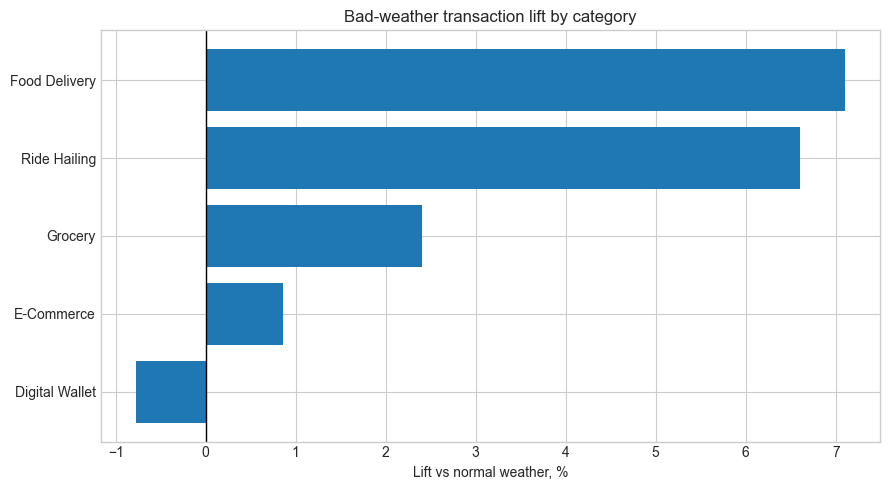

In [94]:
weather_path = REPO_ROOT / "nova" / "seeds" / "ext_weather_daily.csv"
if weather_path.exists():
    weather = (
        pl.read_csv(weather_path, try_parse_dates=True)
        .with_columns(
            pl.col("weather_date").dt.strftime("%Y-%m").alias("month_key"),
            pl.col("precipitation_sum_mm").fill_null(0.0),
            pl.col("wind_speed_10m_max_kmh").fill_null(0.0),
            pl.col("temperature_2m_mean_c").fill_null(strategy="mean"),
        )
    )
    monthly_weather = weather.group_by(["market_id", "month_key"]).agg(
        pl.col("temperature_2m_mean_c").quantile(0.10).alias("month_temp_p10"),
        pl.col("temperature_2m_mean_c").quantile(0.90).alias("month_temp_p90"),
    )
    market_weather = weather.group_by("market_id").agg(
        pl.col("precipitation_sum_mm").quantile(0.90).alias("market_precip_p90"),
        pl.col("wind_speed_10m_max_kmh").quantile(0.90).alias("market_wind_p90"),
    )
    weather_flags = (
        weather
        .join(monthly_weather, on=["market_id", "month_key"], how="left")
        .join(market_weather, on="market_id", how="left")
        .with_columns(
            (
                (pl.col("precipitation_sum_mm") >= pl.max_horizontal(pl.col("market_precip_p90"), pl.lit(8.0)))
                | (pl.col("temperature_2m_mean_c") >= pl.col("month_temp_p90"))
                | (pl.col("temperature_2m_mean_c") <= pl.col("month_temp_p10"))
                | (pl.col("wind_speed_10m_max_kmh") >= pl.max_horizontal(pl.col("market_wind_p90"), pl.lit(28.0)))
            ).alias("is_bad_weather_day")
        )
        .select(
            pl.col("market_id").alias("Market_ID"),
            pl.col("weather_date").alias("Date"),
            "is_rain_day",
            "is_bad_weather_day",
            "temperature_2m_mean_c",
            "precipitation_sum_mm",
            "wind_speed_10m_max_kmh",
        )
    )

    daily_category = (
        corrected_interactions
        .group_by(["Market_ID", "Market_Name", "Category", "Date"])
        .agg(
            pl.len().alias("n_transactions"),
            pl.col("Amount_USD").sum().alias("total_amount_usd"),
            (pl.col("Status") == "Completed").mean().alias("completion_rate"),
        )
        .collect()
        .join(weather_flags, on=["Market_ID", "Date"], how="left")
    )
    weather_category = (
        daily_category
        .group_by("Category")
        .agg(
            pl.col("n_transactions").filter(pl.col("is_bad_weather_day")).mean().alias("bad_weather_avg_transactions"),
            pl.col("n_transactions").filter(~pl.col("is_bad_weather_day")).mean().alias("normal_weather_avg_transactions"),
            pl.col("total_amount_usd").filter(pl.col("is_bad_weather_day")).mean().alias("bad_weather_avg_gmv"),
            pl.col("total_amount_usd").filter(~pl.col("is_bad_weather_day")).mean().alias("normal_weather_avg_gmv"),
            pl.col("completion_rate").filter(pl.col("is_bad_weather_day")).mean().alias("bad_weather_completion_rate"),
            pl.col("completion_rate").filter(~pl.col("is_bad_weather_day")).mean().alias("normal_weather_completion_rate"),
        )
        .with_columns(
            ((pl.col("bad_weather_avg_transactions") - pl.col("normal_weather_avg_transactions")) / pl.col("normal_weather_avg_transactions")).alias("bad_weather_transaction_lift"),
            (pl.col("bad_weather_completion_rate") - pl.col("normal_weather_completion_rate")).alias("bad_weather_completion_delta"),
        )
        .sort("bad_weather_transaction_lift", descending=True)
    )
    display(weather_category.to_pandas())

    weather_pd = weather_category.to_pandas().sort_values("bad_weather_transaction_lift")
    plt.figure(figsize=(9, 5))
    plt.barh(weather_pd["Category"], weather_pd["bad_weather_transaction_lift"] * 100)
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Bad-weather transaction lift by category")
    plt.xlabel("Lift vs normal weather, %")
    plt.tight_layout()
    plt.show()
else:
    print("Weather seed not found; run the external geo seed fetch before weather diagnostics.")


## 15. Analyst-detectable suspicious behavior

The regenerated data should not contain fraud labels. Instead, analysts should be able to discover low-rate suspicious patterns using existing fields: user-hour velocity, category-relative amount anomalies, status outcomes, lifecycle segment, platform, referral source, and category.

When `enable_fraud_behavior` is false, these tables should remain mostly flat. When it is true, the proxy signal should be detectable but still moderate.


,Category,p95_amount_usd,p99_amount_usd
0,E-Commerce,285.77,515.11
1,Ride Hailing,62.18,89.59
2,Digital Wallet,160.47,375.72
3,Grocery,148.23,198.55
4,Food Delivery,59.01,81.45


,user_hours,high_velocity_user_hours,transactions_in_high_velocity_hours,amount_in_high_velocity_hours,high_velocity_non_completion_rate,normal_velocity_non_completion_rate,high_velocity_transaction_share
0,49295927,16626,400495,62092337.32,0.747785,0.085429,0.00801


,suspicious_proxy_share,overall_non_completion_rate,proxy_non_completion_rate,proxy_web_or_lite_share,baseline_web_or_lite_share,proxy_promo_referral_share,baseline_promo_referral_share
0,0.010032,0.090734,0.624025,0.629511,0.32214,0.951083,0.567447


,Category,n_transactions,suspicious_proxy_share,p99_amount_transaction_share,overall_non_completion_rate,p99_amount_non_completion_rate,proxy_non_completion_rate,p99_non_completion_lift,proxy_non_completion_lift
0,Digital Wallet,6011860,0.021318,0.010001,0.034330,0.177955,0.634103,0.143625,0.599773
1,E-Commerce,11003532,0.018559,0.010000,0.134725,0.245704,0.601678,0.110979,0.466953
2,Ride Hailing,11206091,0.005139,0.010004,0.119451,0.116500,0.656114,-0.002951,0.536663
3,Food Delivery,14864352,0.005128,0.010002,0.062297,0.056788,0.633627,-0.005509,0.571329
4,Grocery,6914165,0.005118,0.010001,0.084359,0.081835,0.643590,-0.002524,0.559231


,Category,User_Segment,Lifecycle_Segment,Platform_User_Agent,Referral_Source,transactions,non_completion_rate,suspicious_proxy_share,avg_amount_usd
0,Digital Wallet,New,New Active,Nova Web Portal (Chrome 120.0),Push Notification,117,0.880342,1.000000,452.177436
1,E-Commerce,New,New Active,Nova Web Portal (Chrome 120.0),Push Notification,278,0.582734,0.661871,518.161619
2,E-Commerce,New,New Active,Nova Lite (Android Go),Push Notification,180,0.527778,0.650000,484.998167
3,Digital Wallet,Casual,At Risk,Nova Web Portal (Chrome 120.0),Push Notification,200,0.485000,0.635000,368.602850
4,Digital Wallet,Regular,At Risk,Nova Web Portal (Chrome 120.0),Social Ad,116,0.500000,0.620690,343.999310
5,Digital Wallet,Casual,At Risk,Nova Lite (Android Go),Push Notification,136,0.522059,0.602941,358.957279
6,Digital Wallet,New,New Active,Nova Web Portal (Chrome 120.0),Social Ad,328,0.451220,0.564024,362.371707
7,Digital Wallet,Casual,At Risk,Nova Web Portal (Chrome 120.0),Social Ad,332,0.388554,0.539157,332.389307
8,E-Commerce,New,New Active,Nova Web Portal (Chrome 120.0),Social Ad,501,0.455090,0.530938,445.331078
9,E-Commerce,New,New Active,Nova Lite (Android Go),Social Ad,356,0.443820,0.528090,464.525140


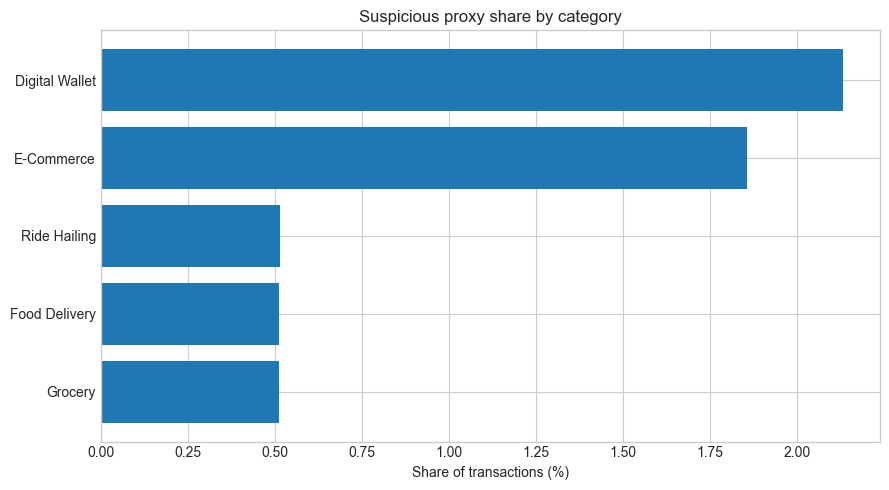

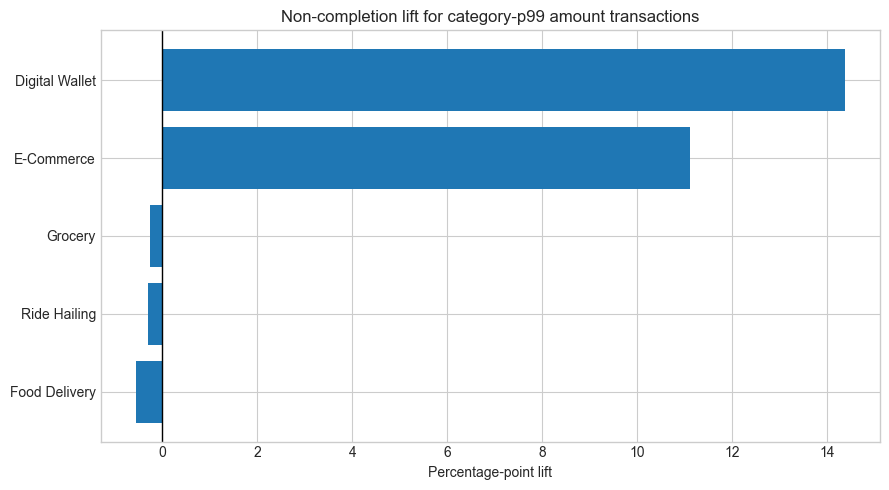

In [95]:
category_amount_thresholds = (
    corrected_interactions
    .group_by("Category")
    .agg(
        pl.col("Amount_USD").quantile(0.95).alias("p95_amount_usd"),
        pl.col("Amount_USD").quantile(0.99).alias("p99_amount_usd"),
    )
    .collect()
)
display(category_amount_thresholds.to_pandas())

user_hour_velocity = (
    corrected_interactions
    .group_by(["User_ID", "Date", "Hour"])
    .agg(
        pl.len().alias("transactions_in_user_hour"),
        pl.col("Amount_USD").sum().alias("amount_in_user_hour"),
        (pl.col("Status") != "Completed").sum().alias("non_completed_in_user_hour"),
        pl.col("Category").n_unique().alias("categories_in_user_hour"),
    )
    .with_columns((pl.col("transactions_in_user_hour") >= 3).alias("is_high_velocity_user_hour"))
    .collect()
)

row_count = corrected_interactions.select(pl.len().alias("n_transactions")).collect()["n_transactions"][0]
velocity_summary = user_hour_velocity.select(
    pl.len().alias("user_hours"),
    pl.col("is_high_velocity_user_hour").sum().alias("high_velocity_user_hours"),
    pl.col("transactions_in_user_hour").filter(pl.col("is_high_velocity_user_hour")).sum().alias("transactions_in_high_velocity_hours"),
    pl.col("amount_in_user_hour").filter(pl.col("is_high_velocity_user_hour")).sum().alias("amount_in_high_velocity_hours"),
    (
        pl.col("non_completed_in_user_hour").filter(pl.col("is_high_velocity_user_hour")).sum()
        / pl.col("transactions_in_user_hour").filter(pl.col("is_high_velocity_user_hour")).sum()
    ).alias("high_velocity_non_completion_rate"),
    (
        pl.col("non_completed_in_user_hour").filter(~pl.col("is_high_velocity_user_hour")).sum()
        / pl.col("transactions_in_user_hour").filter(~pl.col("is_high_velocity_user_hour")).sum()
    ).alias("normal_velocity_non_completion_rate"),
).with_columns(
    (pl.col("transactions_in_high_velocity_hours") / row_count).alias("high_velocity_transaction_share")
)
display(velocity_summary.to_pandas())

interactions_with_risk_proxies = (
    corrected_interactions
    .join(category_amount_thresholds.lazy(), on="Category", how="left")
    .join(
        user_hour_velocity.select(["User_ID", "Date", "Hour", "transactions_in_user_hour"]).lazy(),
        on=["User_ID", "Date", "Hour"],
        how="left",
    )
    .with_columns(
        (pl.col("Amount_USD") >= pl.col("p95_amount_usd")).alias("is_category_p95_amount"),
        (pl.col("Amount_USD") >= pl.col("p99_amount_usd")).alias("is_category_p99_amount"),
        (pl.col("transactions_in_user_hour") >= 3).alias("is_high_velocity_user_hour"),
        (pl.col("Status") != "Completed").alias("is_non_completed"),
        ((pl.col("User_Segment") == "New") | (pl.col("Lifecycle_Segment") == "At Risk")).alias("is_new_or_at_risk"),
        pl.col("Category").is_in(["Digital Wallet", "E-Commerce"]).alias("is_signal_category"),
        pl.col("Platform_User_Agent").str.contains("Web Portal|Nova Lite").alias("is_web_or_lite"),
        pl.col("Referral_Source").is_in(["Social Ad", "Email Promo", "Push Notification"]).alias("is_promo_referral"),
    )
    .with_columns(
        (
            (pl.col("is_high_velocity_user_hour") | (pl.col("is_category_p99_amount") & pl.col("is_signal_category")))
            & (
                pl.col("is_non_completed")
                | pl.col("is_new_or_at_risk")
                | pl.col("is_web_or_lite")
                | pl.col("is_promo_referral")
            )
        ).alias("is_suspicious_proxy")
    )
)

proxy_summary = interactions_with_risk_proxies.select(
    pl.col("is_suspicious_proxy").mean().alias("suspicious_proxy_share"),
    pl.col("is_non_completed").mean().alias("overall_non_completion_rate"),
    pl.col("is_non_completed").filter(pl.col("is_suspicious_proxy")).mean().alias("proxy_non_completion_rate"),
    pl.col("is_web_or_lite").filter(pl.col("is_suspicious_proxy")).mean().alias("proxy_web_or_lite_share"),
    pl.col("is_web_or_lite").filter(~pl.col("is_suspicious_proxy")).mean().alias("baseline_web_or_lite_share"),
    pl.col("is_promo_referral").filter(pl.col("is_suspicious_proxy")).mean().alias("proxy_promo_referral_share"),
    pl.col("is_promo_referral").filter(~pl.col("is_suspicious_proxy")).mean().alias("baseline_promo_referral_share"),
).collect()
display(proxy_summary.to_pandas())

category_proxy_summary = (
    interactions_with_risk_proxies
    .group_by("Category")
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("is_suspicious_proxy").mean().alias("suspicious_proxy_share"),
        pl.col("is_category_p99_amount").mean().alias("p99_amount_transaction_share"),
        pl.col("is_non_completed").mean().alias("overall_non_completion_rate"),
        pl.col("is_non_completed").filter(pl.col("is_category_p99_amount")).mean().alias("p99_amount_non_completion_rate"),
        pl.col("is_non_completed").filter(pl.col("is_suspicious_proxy")).mean().alias("proxy_non_completion_rate"),
    )
    .with_columns(
        (pl.col("p99_amount_non_completion_rate") - pl.col("overall_non_completion_rate")).alias("p99_non_completion_lift"),
        (pl.col("proxy_non_completion_rate") - pl.col("overall_non_completion_rate")).alias("proxy_non_completion_lift"),
    )
    .sort("suspicious_proxy_share", descending=True)
    .collect()
)
display(category_proxy_summary.to_pandas())

new_at_risk_amount_risk = (
    interactions_with_risk_proxies
    .filter(pl.col("is_new_or_at_risk") & pl.col("is_category_p95_amount"))
    .group_by(["Category", "User_Segment", "Lifecycle_Segment", "Platform_User_Agent", "Referral_Source"])
    .agg(
        pl.len().alias("transactions"),
        pl.col("is_non_completed").mean().alias("non_completion_rate"),
        pl.col("is_suspicious_proxy").mean().alias("suspicious_proxy_share"),
        pl.col("Amount_USD").mean().alias("avg_amount_usd"),
    )
    .filter(pl.col("transactions") >= 100)
    .sort(["suspicious_proxy_share", "non_completion_rate"], descending=[True, True])
    .collect()
)
display(new_at_risk_amount_risk.head(20).to_pandas())

category_proxy_pd = category_proxy_summary.to_pandas().sort_values("suspicious_proxy_share")
plt.figure(figsize=(9, 5))
plt.barh(category_proxy_pd["Category"], category_proxy_pd["suspicious_proxy_share"] * 100)
plt.title("Suspicious proxy share by category")
plt.xlabel("Share of transactions (%)")
plt.tight_layout()
plt.show()

lift_pd = category_proxy_summary.to_pandas().sort_values("p99_non_completion_lift")
plt.figure(figsize=(9, 5))
plt.barh(lift_pd["Category"], lift_pd["p99_non_completion_lift"] * 100)
plt.axvline(0, color="black", linewidth=1)
plt.title("Non-completion lift for category-p99 amount transactions")
plt.xlabel("Percentage-point lift")
plt.tight_layout()
plt.show()


## 16. Early synthetic-behavior guardrails

These diagnostics are meant to fail fast when regenerated dimensions are present but not behaviorally meaningful. Use them before trusting dashboard or modeling outputs.


,User_Segment,activity_range_pct,non_completion_range
0,Casual,0.676239,0.026752
1,Power,0.298991,0.009031
2,Regular,0.640943,0.026663


,Category,share_std,min_share,max_share,avg_amount_std,completion_rate_std
0,Digital Wallet,0.015797,0.098574,0.149191,12.606996,0.004082
1,E-Commerce,0.036011,0.175331,0.282949,29.500564,0.006899
2,Food Delivery,0.032569,0.248095,0.348468,7.841687,0.008006
3,Grocery,0.016166,0.120968,0.169762,21.503390,0.007962
4,Ride Hailing,0.019679,0.185572,0.252763,7.690718,0.007858


,market_pairs,min_corr,median_corr,max_corr
0,256,0.974533,0.989839,0.999975


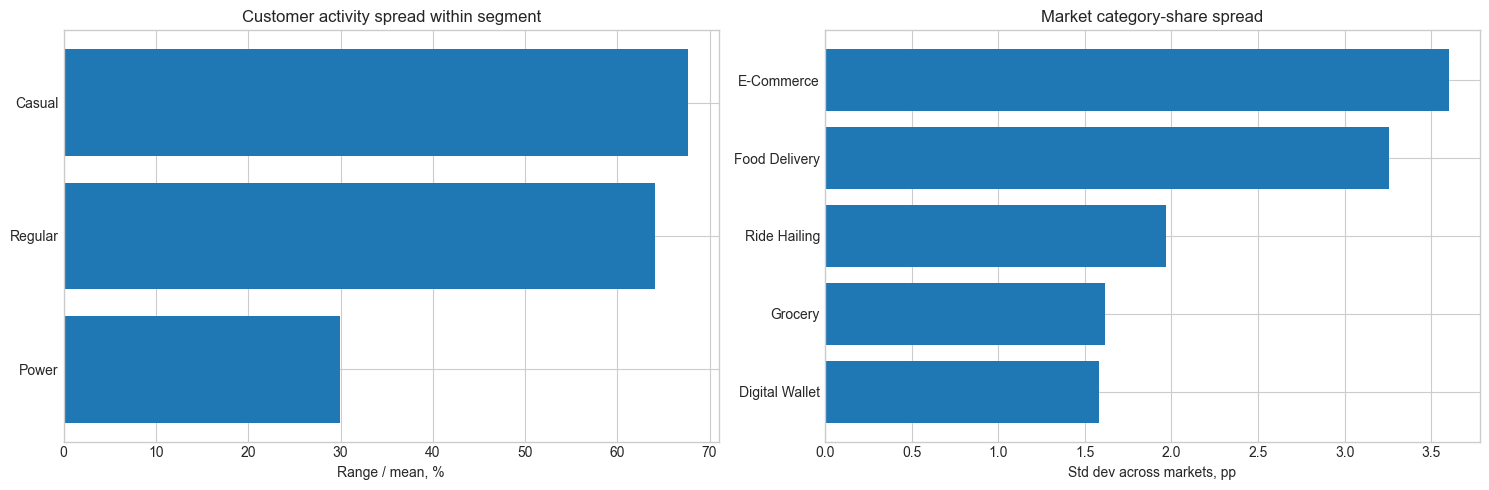

In [96]:
guardrail_customer = (
    corrected_interactions
    .group_by("User_ID")
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
        (pl.col("Status") != "Completed").sum().alias("non_completed_transactions"),
    )
    .collect()
    .join(corrected_users, on="User_ID", how="left")
    .with_columns(
        (pl.col("non_completed_transactions") / pl.col("n_transactions")).alias("non_completion_rate")
    )
    .group_by(["User_Segment", "Lifecycle_Segment", "Membership_Tier"])
    .agg(
        pl.len().alias("active_users"),
        pl.col("n_transactions").mean().alias("avg_transactions"),
        pl.col("total_amount_usd").mean().alias("avg_total_amount_usd"),
        pl.col("non_completion_rate").mean().alias("avg_non_completion_rate"),
    )
)
customer_spread = (
    guardrail_customer
    .filter(pl.col("User_Segment").is_in(["Casual", "Regular", "Power"]))
    .group_by("User_Segment")
    .agg(
        ((pl.col("avg_transactions").max() - pl.col("avg_transactions").min()) / pl.col("avg_transactions").mean()).alias("activity_range_pct"),
        (pl.col("avg_non_completion_rate").max() - pl.col("avg_non_completion_rate").min()).alias("non_completion_range"),
    )
    .sort("User_Segment")
)
display(customer_spread.to_pandas())

market_category_guardrail = (
    corrected_interactions
    .group_by(["Market_ID", "Market_Name", "Category"])
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("Amount_USD").mean().alias("avg_amount_usd"),
        (pl.col("Status") == "Completed").mean().alias("completion_rate"),
    )
    .with_columns((pl.col("n_transactions") / pl.col("n_transactions").sum().over("Market_ID")).alias("market_category_share"))
    .collect()
)
market_category_spread = market_category_guardrail.group_by("Category").agg(
    pl.col("market_category_share").std().alias("share_std"),
    pl.col("market_category_share").min().alias("min_share"),
    pl.col("market_category_share").max().alias("max_share"),
    pl.col("avg_amount_usd").std().alias("avg_amount_std"),
    pl.col("completion_rate").std().alias("completion_rate_std"),
).sort("Category")
display(market_category_spread.to_pandas())

market_monthly = (
    corrected_interactions
    .group_by(["Market_Name", "Month"])
    .agg(pl.len().alias("n_transactions"))
    .sort(["Market_Name", "Month"])
    .collect()
    .to_pandas()
)
monthly_wide = market_monthly.pivot(index="Month", columns="Market_Name", values="n_transactions")
monthly_corr = monthly_wide.corr()
upper_corr = monthly_corr.where(np.triu(np.ones(monthly_corr.shape), k=1).astype(bool)).stack()
monthly_corr_summary = pd.DataFrame([
    {
        "market_pairs": len(upper_corr),
        "min_corr": upper_corr.min(),
        "median_corr": upper_corr.median(),
        "max_corr": upper_corr.max(),
    }
])
display(monthly_corr_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
customer_plot = customer_spread.to_pandas().sort_values("activity_range_pct")
axes[0].barh(customer_plot["User_Segment"], customer_plot["activity_range_pct"] * 100)
axes[0].set_title("Customer activity spread within segment")
axes[0].set_xlabel("Range / mean, %")
category_plot = market_category_spread.to_pandas().sort_values("share_std")
axes[1].barh(category_plot["Category"], category_plot["share_std"] * 100)
axes[1].set_title("Market category-share spread")
axes[1].set_xlabel("Std dev across markets, pp")
plt.tight_layout()
plt.show()


## 17. Interpretation checklist

The corrected dataset now supports a more credible business narrative:

- Growth: monthly transactions rise through 2024 and Q4 is stronger.
- Seasonality: daily and hourly profiles are no longer flat.
- Category realism: amount and reliability differ by category.
- Platform realism: web has lower completion than native app surfaces.
- Merchant realism: service volume has a head/mid/long-tail shape.
- Geography: transactions belong to named global city markets instead of random world coordinates.
- Lifecycle: not every user is identical; corrected users include lifecycle and activity segments.
- Weather, when enabled: bad-weather demand lift should be strongest in Ride Hailing and Food Delivery, moderate in Grocery, and weakest in Digital Wallet.
- Suspicious behavior, when enabled: there are no fraud labels, but analysts should see low-rate detectable patterns through velocity, non-completion, amount, lifecycle, and platform/referral proxies.

Use `data/corrected/` for BigQuery ingestion after the validation checks remain green.

